In [21]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from scipy.stats import gaussian_kde
import sys
sys.path.append('../../')

from mcjax.process.ou import OU
from mcjax.proba.gaussian import IsotropicGauss, MixedIsotropicGauss



In [2]:
# Config
mu = jnp.array([[2.0, 0.0], [-2.0, 0.0]])
log_var = jnp.log(jnp.array([0.1, 0.1]))
weights = jnp.array([0.5, 0.5])
mix = MixedIsotropicGauss(mu=mu, log_var=log_var, weights=weights)
K, D = mu.shape

L = 100
beta_const = 0.02  
alpha = jnp.ones(L) * beta_const
sigma = 1.0
ou = OU(T=L, alpha=alpha, sigma=sigma, init_dist=mix)

In [3]:
# Calculate Score function for mixed gaussian initial distribution
sigma0 = jnp.exp(0.5 * log_var)
inv_sigma0_sq = 1.0 / (sigma0 ** 2)
log_w = jnp.log(weights + 1e-12)
bar_alpha = jnp.cumprod(1.0 - alpha)
sigma2 = 1.0 - bar_alpha


def component_log_marginal(x, k):
    c = jnp.sqrt(bar_alpha[k])
    var_k = sigma2[k] + bar_alpha[k] * (sigma0 ** 2)
    diff = x[None, :] - c * mu
    quad = jnp.sum(diff**2 / var_k[:, None], axis=-1)
    logdet = D * jnp.log(2.0 * jnp.pi * var_k)
    return -0.5 * (quad + logdet)

def posterior_mean_component(x, k):
    c = jnp.sqrt(bar_alpha[k])
    sig2 = sigma2[k]
    denom = inv_sigma0_sq + c**2 / (sig2 + 1e-12)
    Sigma_post = 1.0 / (denom + 1e-12)
    term = (inv_sigma0_sq[:, None] * mu) + ((c / (sig2 + 1e-12)) * x[None, :])
    return Sigma_post[:, None] * term

def responsibilities(x, k):
    logp = log_w + component_log_marginal(x, k)
    return jax.nn.softmax(logp)

def E_x0_given_xk(x, k):
    m_post = posterior_mean_component(x, k)
    gamma = responsibilities(x, k)
    return jnp.sum(gamma[:, None] * m_post, axis=0)

def score_fn(params, k, x_batch):
    c = jnp.sqrt(bar_alpha[k])
    sig2 = sigma2[k] + 1e-12
    def single(x):
        ex0 = E_x0_given_xk(x, k)
        return (c * ex0 - x) / sig2
    return jax.vmap(single)(x_batch)



In [4]:
# Simulate forward & reverse processes
key = jr.PRNGKey(0)
N = 10_000

# Forward diffusion samples
x_forward = [ou.sample(key, N, k) for k in range(L + 1)]

# Backward denoising samples
xT = x_forward[-1]
key, subkey = jr.split(key)
x_reverse_all = [xT]
for i in range(L):
    key, y, _ = ou.reverse_step(key, x_reverse_all[-1], i, score_fn, params=None)
    x_reverse_all.append(y)
x_reverse_all = x_reverse_all[::-1] 

In [5]:
# timesteps to plot
selected_steps = [0, L // 4, L // 2, 3 * L // 4, L]
titles = [f"t = {k}" for k in selected_steps]

In [18]:
def plot_density(ax, samples, title):
    """Contour density only (no streamlines)."""
    samples = np.array(samples)
    x, y = samples[:, 0], samples[:, 1]
    xmin, xmax, ymin, ymax = -4.5, 4.5, -4.5, 4.5

    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 150),
                         np.linspace(ymin, ymax, 150))
    positions = np.vstack([xx.ravel(), yy.ravel()])
    kde = gaussian_kde(np.vstack([x, y]))
    zz = np.reshape(kde(positions), xx.shape)
    ax.contourf(xx, yy, zz, levels=25, cmap="coolwarm")

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

def plot_density_with_stream(ax, samples, title, k):
    """Contour + streamlines of score field (for reverse chain)."""
    samples = np.array(samples)
    x, y = samples[:, 0], samples[:, 1]
    xmin, xmax, ymin, ymax = -4.5, 4.5, -4.5, 4.5

    # Contour density
    xx, yy = np.meshgrid(np.linspace(xmin, xmax, 150),
                         np.linspace(ymin, ymax, 150))
    positions = np.vstack([xx.ravel(), yy.ravel()])
    kde = gaussian_kde(np.vstack([x, y]))
    zz = np.reshape(kde(positions), xx.shape)
    ax.contourf(xx, yy, zz, levels=25, cmap="coolwarm")

    # Score field streamlines
    grid = jnp.stack([jnp.ravel(jnp.array(xx)), jnp.ravel(jnp.array(yy))], axis=-1)
    score_grid = np.array(score_fn(None, k, grid))
    U = np.reshape(score_grid[:, 0], xx.shape)
    V = np.reshape(score_grid[:, 1], yy.shape)
    xx, yy, U, V = map(lambda a: np.asarray(a, dtype=np.float64), (xx, yy, U, V))
    ax.streamplot(xx, yy, U, V,
                  color="k", linewidth=0.4, density=0.2, arrowsize=1.0)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

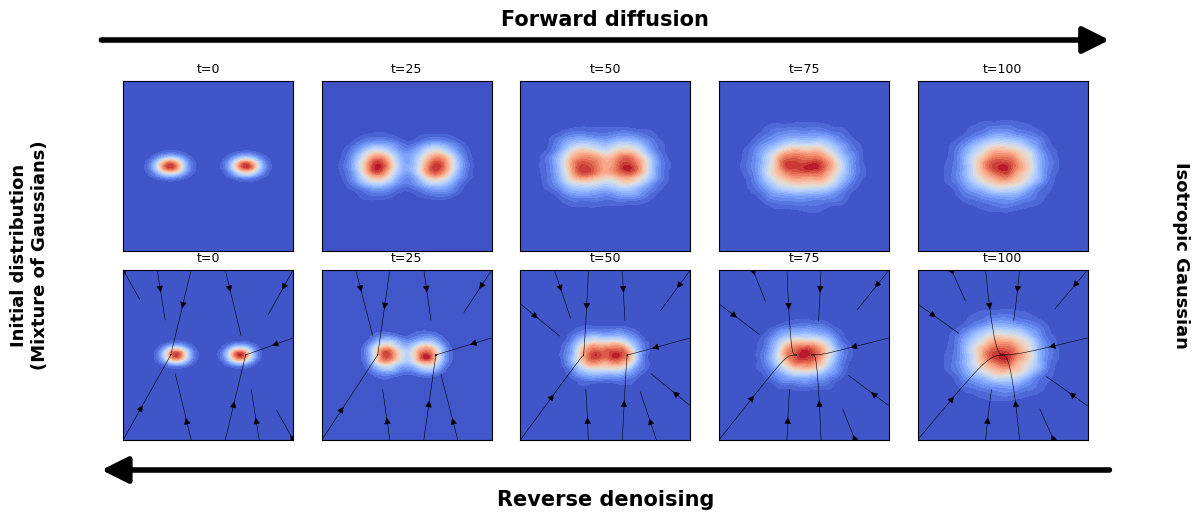

In [ ]:
fig, axes = plt.subplots(2, len(selected_steps), figsize=(12, 5))

for j, k in enumerate(selected_steps):
    plot_density(axes[0, j], x_forward[k], f"t={k}")
    plot_density_with_stream(axes[1, j], x_reverse_all[k], f"t={k}", k)


# Adjust layout and add space around figure
plt.tight_layout(rect=[0.08, 0.1, 0.92, 0.9])

fig.text(0.02, 0.5, "Initial distribution\n(Mixture of Gaussians)",
         va="center", ha="center", fontsize=13, fontweight="bold", rotation=90)
fig.text(0.98, 0.5, "Isotropic Gaussian",
         va="center", ha="center", fontsize=13, fontweight="bold", rotation=270)

# Arrows and titles
# Forward (top)
arrow_top = mpatches.FancyArrowPatch(
    posA=(0.08, 0.93), posB=(0.92, 0.93),
    transform=fig.transFigure, arrowstyle='-|>', mutation_scale=40,
    linewidth=4, color='black', shrinkA=0, shrinkB=0
)
fig.patches.append(arrow_top)
fig.text(0.5, 0.95, "Forward diffusion", ha="center", va="bottom", fontsize=15, fontweight="bold")

# Reverse (bottom)
arrow_bottom = mpatches.FancyArrowPatch(
    posA=(0.92, 0.07), posB=(0.08, 0.07),
    transform=fig.transFigure, arrowstyle='-|>', mutation_scale=40,
    linewidth=4, color='black', shrinkA=0, shrinkB=0
)
fig.patches.append(arrow_bottom)
fig.text(0.5, 0.03, "Reverse denoising", ha="center", va="top", fontsize=15, fontweight="bold")

plt.show()